In [1]:
# https://drive.google.com/file/d/1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo/view?usp=sharing

In [2]:
import os

# Install gdown if not already installed
!pip install gdown

In [3]:
# Extract file ID from the Google Drive link
file_id = '1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo'
output_filename = 'archive.zip' # Assuming the file is a zip archive

# Download the file using gdown
!gdown --id "{file_id}" -O "{output_filename}"

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo
From (redirected): https://drive.google.com/uc?id=1OMzX1cDWbdyG3YtbyqfUEjXp57kj-9Yo&confirm=t&uuid=55c14ed1-ba6e-4892-a883-a089337d77db
To: /content/archive.zip
100% 323M/323M [00:02<00:00, 119MB/s]


In [4]:
import zipfile

# Unzip the downloaded file
if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Successfully unzipped {output_filename}")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: {output_filename} not found. Download might have failed.")

Successfully unzipped archive.zip


In [5]:
# List the contents of the current directory to see the unzipped files
!ls -F

archive.zip  README.dataset.txt   sample_data/	train/
data.yaml    README.roboflow.txt  test/		valid/


libraries

In [6]:
!pip install torch torchvision
!pip install opencv-python matplotlib
!pip install pycocotools

In [7]:
import os
import json
import cv2

In [8]:
def yolo_to_coco(yolo_folder, image_folder, output_json):
    coco = {
        "images": [],
        "annotations": [],
        "categories": []
    }

    category_set = set()
    annotation_id = 0
    image_id = 0

    for img_file in os.listdir(image_folder):
        if not img_file.endswith(".jpg") and not img_file.endswith(".png"):
            continue

        img_path = os.path.join(image_folder, img_file)
        label_path = os.path.join(yolo_folder, img_file.replace(".jpg", ".txt").replace(".png", ".txt"))

        img = cv2.imread(img_path)
        h, w, _ = img.shape

        coco["images"].append({
            "id": image_id,
            "file_name": img_file,
            "height": h,
            "width": w
        })

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x, y, bw, bh = map(float, line.split())

                    # Shift class ID by 1, as Faster R-CNN reserves 0 for background
                    shifted_cls = int(cls) +1

                    x_min = (x - bw/2) * w
                    y_min = (y - bh/2) * h
                    x_max = (x + bw/2) * w
                    y_max = (y + bh/2) * h

                    coco["annotations"].append({
                        "id": annotation_id,
                        "image_id": image_id,
                        "category_id": shifted_cls,
                        "bbox": [x_min, y_min, x_max - x_min, y_max - y_min],
                        "area": (x_max - x_min) * (y_max - y_min),
                        "iscrowd": 0
                    })

                    category_set.add(shifted_cls)
                    annotation_id += 1

        image_id += 1

    for cat in sorted(category_set):
        coco["categories"].append({
            "id": cat,
            "name": f"class_{cat}"
        })

    with open(output_json, "w") as f:
        json.dump(coco, f)

    print("Saved:", output_json)

In [9]:
!rm train.json valid.json test.json

rm: cannot remove 'train.json': No such file or directory
rm: cannot remove 'valid.json': No such file or directory
rm: cannot remove 'test.json': No such file or directory


In [10]:
yolo_to_coco("train/labels", "train/images", "train.json")
yolo_to_coco("valid/labels", "valid/images", "valid.json")
yolo_to_coco("test/labels", "test/images", "test.json")

Saved: train.json
Saved: valid.json
Saved: test.json


In [11]:
from torch.utils.data import Dataset
import torch
from PIL import Image
from pycocotools.coco import COCO

class CustomCocoDataset(Dataset):
    def __init__(self, img_dir, annotation_file):
        self.img_dir = img_dir
        self.coco = COCO(annotation_file)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        img_info = coco.loadImgs(img_id)[0]
        path = img_info['file_name']

        img = Image.open(os.path.join(self.img_dir, path)).convert("RGB")

        boxes = []
        labels = []

        for ann in anns:
            x, y, w, h = ann['bbox']
            boxes.append([x, y, x+w, y+h])
            labels.append(ann['category_id'])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id])
        }

        return img, target

    def __len__(self):
        return len(self.ids)

In [12]:

from torch.utils.data import DataLoader

train_dataset = CustomCocoDataset("train/images", "train.json")

valid_dataset = CustomCocoDataset("valid/images", "valid.json")
test_dataset = CustomCocoDataset("test/images", "test.json")

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          collate_fn=lambda x: tuple(zip(*x)))
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False,
                         collate_fn=lambda x: tuple(zip(*x)))
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                         collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [13]:
import torchvision
from torchvision.models.detection import ssd300_vgg16
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models import VGG16_Weights
from torchvision.models.detection import SSD300_VGG16_Weights


# def get_ssd_model(num_classes):
#     model = ssd300_vgg16(weights="DEFAULT")

#     # Replace classification head properly
#     in_channels = model.backbone.out_channels
#     num_anchors = model.anchor_generator.num_anchors_per_location()

#     from torchvision.models.detection.ssd import SSDHead

#     model.head = SSDHead(in_channels, num_anchors, num_classes)

#     return model

In [14]:


import json
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open("train.json") as f:
    data = json.load(f)

num_classes = len(data["categories"]) + 1  # background



# Load backbone weights only

model = ssd300_vgg16(
    weights=None,                         # ❗ no COCO head
    weights_backbone=VGG16_Weights.DEFAULT,  # ✅ correct backbone weights
    num_classes=num_classes
)

model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 171MB/s]


In [16]:
import torchvision.transforms as T

transform = T.ToTensor()
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for images, targets in train_loader:
        images = [transform(img).to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 33.6886
Epoch 2, Loss: 29.5466
Epoch 3, Loss: 27.8278
Epoch 4, Loss: 26.8317
Epoch 5, Loss: 27.1837
Epoch 6, Loss: 22.2435
Epoch 7, Loss: 19.6181
Epoch 8, Loss: 19.3498
Epoch 9, Loss: 22.4303
Epoch 10, Loss: 20.9381
Epoch 11, Loss: 17.7725
Epoch 12, Loss: 15.7731
Epoch 13, Loss: 16.6893
Epoch 14, Loss: 14.4489
Epoch 15, Loss: 12.3771
Epoch 16, Loss: 10.2761
Epoch 17, Loss: 9.8500
Epoch 18, Loss: 11.8211
Epoch 19, Loss: 10.4496
Epoch 20, Loss: 10.4550
Epoch 21, Loss: 9.9734
Epoch 22, Loss: 11.1196
Epoch 23, Loss: 11.6342
Epoch 24, Loss: 11.2221
Epoch 25, Loss: 10.5536
Epoch 26, Loss: 9.8219
Epoch 27, Loss: 8.6234
Epoch 28, Loss: 7.8509
Epoch 29, Loss: 7.3257
Epoch 30, Loss: 7.6187
Epoch 31, Loss: 6.4411
Epoch 32, Loss: 7.1999
Epoch 33, Loss: 6.0322
Epoch 34, Loss: 5.6312
Epoch 35, Loss: 5.2805
Epoch 36, Loss: 4.7509
Epoch 37, Loss: 4.3319
Epoch 38, Loss: 4.7016
Epoch 39, Loss: 5.2709
Epoch 40, Loss: 4.7396
Epoch 41, Loss: 5.1822
Epoch 42, Loss: 4.2485
Epoch 43, Loss: 4.05

model evaluation

In [17]:

import torchvision.transforms as T
from tqdm import tqdm

model.eval()
transform = T.ToTensor()

results = []

with torch.no_grad():
    for images, targets in tqdm(test_loader):
        images = [transform(img).to(device) for img in images]
        outputs = model(images)

        for i, output in enumerate(outputs):
            boxes = output['boxes'].cpu().numpy()
            scores = output['scores'].cpu().numpy()
            labels = output['labels'].cpu().numpy()

            image_id = targets[i]["image_id"].item()

            for box, score, label in zip(boxes, scores, labels):
                if score < 0.5:   # 🔥 threshold (adjust if needed)
                    continue

                x_min, y_min, x_max, y_max = box

                results.append({
                    "image_id": image_id,
                    "category_id": int(label),
                    "bbox": [
                        float(x_min),
                        float(y_min),
                        float(x_max - x_min),
                        float(y_max - y_min)
                    ],
                    "score": float(score)
                })

100%|██████████| 15/15 [00:10<00:00,  1.40it/s]


In [18]:
with open("predictions.json", "w") as f:
    json.dump(results, f)

print("✅ predictions.json saved!")

✅ predictions.json saved!


In [19]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO("test.json")
coco_dt = coco_gt.loadRes("predictions.json")

coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.07s).
Accumulating evaluation results...
DONE (t=0.02s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.007
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.028
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.007
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.008
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.020
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [20]:
import numpy as np

def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter = max(0, x2-x1) * max(0, y2-y1)

    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])

    union = area1 + area2 - inter

    return inter / (union + 1e-6)

In [21]:
tp, fp, fn = 0, 0, 0
iou_threshold = 0.5

model.eval()

with torch.no_grad():
    for images, targets in test_loader:
        images = [T.ToTensor()(img).to(device) for img in images]
        outputs = model(images)

        for output, target in zip(outputs, targets):

            pred_boxes = output['boxes'].cpu().numpy()
            pred_labels = output['labels'].cpu().numpy()
            scores = output['scores'].cpu().numpy()

            gt_boxes = target['boxes'].numpy()
            gt_labels = target['labels'].numpy()

            matched = set()

            for pb, pl, score in zip(pred_boxes, pred_labels, scores):
                if score < 0.5:
                    continue

                found_match = False

                for i, (gb, gl) in enumerate(zip(gt_boxes, gt_labels)):
                    if i in matched:
                        continue

                    iou = compute_iou(pb, gb)

                    if iou >= iou_threshold and pl == gl:
                        tp += 1
                        matched.add(i)
                        found_match = True
                        break

                if not found_match:
                    fp += 1

            fn += len(gt_boxes) - len(matched)

In [22]:
precision = tp / (tp + fp + 1e-6)
recall = tp / (tp + fn + 1e-6)
f1 = 2 * precision * recall / (precision + recall + 1e-6)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Precision: 0.4364
Recall: 0.0863
F1 Score: 0.1441


visualizing

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torchvision.transforms as T

id_to_class = {
    1: 'Grass',
    2: 'Sorghum',
    3: 'Weed'
}

def visualize_predictions(model, dataset, device, num_images=5, threshold=0.5):
    model.eval()
    transform = T.ToTensor()

    for i in range(num_images):
        img, target = dataset[i]
        img_tensor = transform(img).to(device)

        with torch.no_grad():
            output = model([img_tensor])[0]

        fig, ax = plt.subplots(1, figsize=(8, 6))
        ax.imshow(img)

        for box, score, label in zip(output['boxes'], output['scores'], output['labels']):
            if score < threshold:
                continue

            x_min, y_min, x_max, y_max = box.cpu().numpy()
            label = label.item()

            class_name = id_to_class.get(label, "Unknown")

            rect = patches.Rectangle(
                (x_min, y_min),
                x_max - x_min,
                y_max - y_min,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )
            ax.add_patch(rect)

            ax.text(
                x_min,
                y_min - 5,
                f"{class_name} ({score:.2f})",
                color='red',
                fontsize=10,
                backgroundcolor='white'
            )

        ax.set_title(f"Image {i}")
        plt.axis("off")
        plt.show()


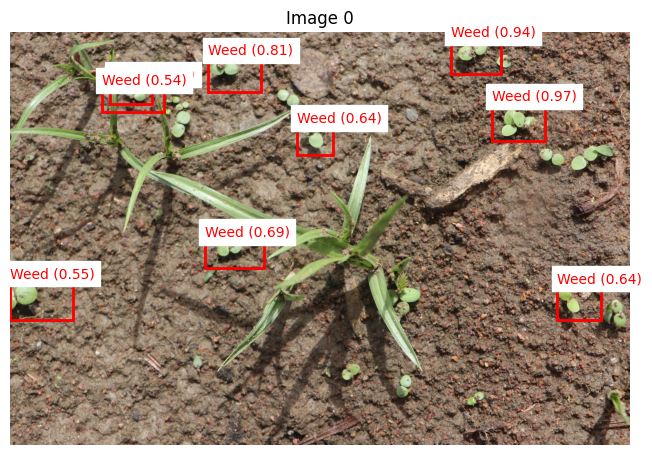

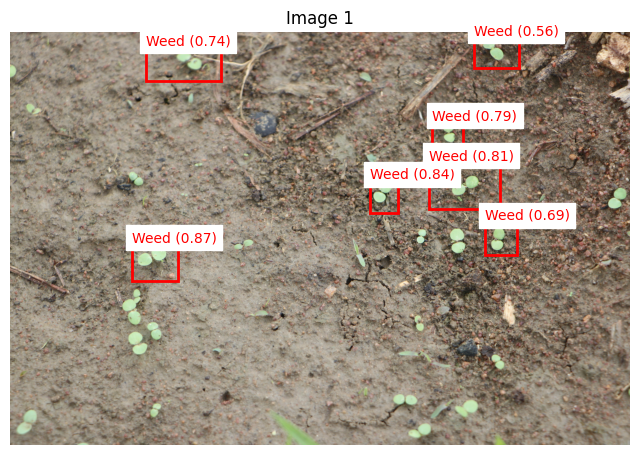

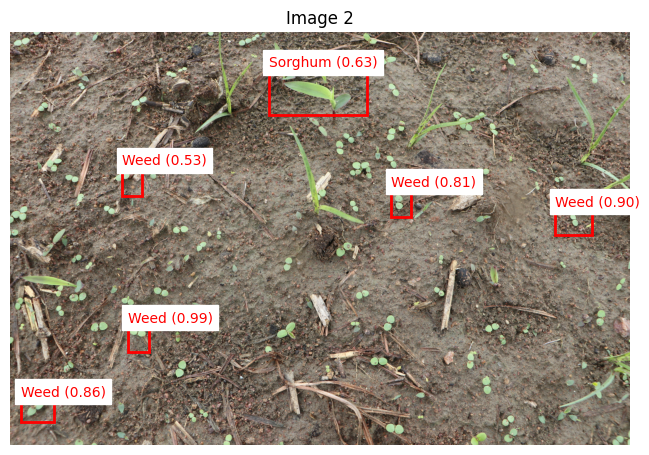

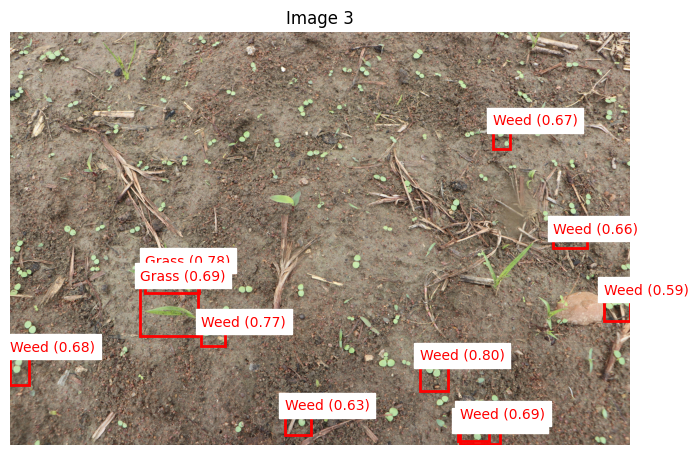

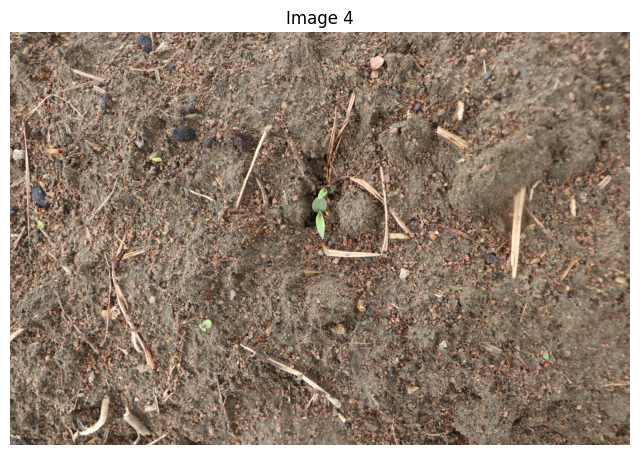

In [24]:
visualize_predictions(model, test_dataset, device, num_images=5, threshold=0.5)